In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.21.0


In [56]:
# Đường dẫn dữ liệu
DATA_DIR = '../data'

# Đọc file sales
df = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'sales_cleaned.csv'), parse_dates=['Date'])

# Đọc file promotions
promo = pd.read_csv(os.path.join(DATA_DIR, 'raw', 'promotions.csv'), parse_dates=['start_date', 'end_date'])

print(f"Sales data: {df.shape}")
print(f"Promotions data: {promo.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print("\nFirst 5 rows of sales:")
print(df.head())

Sales data: (3833, 3)
Promotions data: (50, 10)
Date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00

First 5 rows of sales:
        Date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79


In [57]:
def create_promo_features(promo, start_date, end_date):
    """Tạo daily features từ promotions"""
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    daily = pd.DataFrame({'Date': date_range})
    
    promo_features = []
    for _, row in promo.iterrows():
        start = row['start_date']
        end = row['end_date']
        mask = (daily['Date'] >= start) & (daily['Date'] <= end)
        active_dates = daily.loc[mask, 'Date']
        
        for d in active_dates:
            promo_features.append({
                'Date': d,
                'num_active_promos': 1,
                'avg_discount': row['discount_value']
            })
    
    if not promo_features:
        daily['num_active_promos'] = 0
        daily['avg_discount'] = 0
        return daily
    
    promo_df = pd.DataFrame(promo_features)
    promo_daily = promo_df.groupby('Date').agg({
        'num_active_promos': 'sum',
        'avg_discount': 'mean'
    }).reset_index()
    
    daily = daily.merge(promo_daily, on='Date', how='left')
    daily = daily.fillna(0)
    
    return daily

# Tạo promo features
promo_features = create_promo_features(promo, df['Date'].min(), df['Date'].max())
print(f"Promo features shape: {promo_features.shape}")

Promo features shape: (3833, 3)


In [58]:
# Merge dữ liệu
data = df.merge(promo_features, on='Date', how='left')

# Time features
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data['dayofweek'] = data['Date'].dt.dayofweek
data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)

# Holidays
holidays = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
data['is_holiday'] = data['Date'].dt.strftime('%m-%d').isin(holidays).astype(int)

# Sin/Cos cho ngày trong năm
data['dayofyear_sin'] = np.sin(2 * np.pi * data['Date'].dt.dayofyear / 365.25)
data['dayofyear_cos'] = np.cos(2 * np.pi * data['Date'].dt.dayofyear / 365.25)

# Lag features
lags = [1, 2, 3, 7, 14, 30]
for lag in lags:
    data[f'Revenue_lag_{lag}'] = data['Revenue'].shift(lag)
    data[f'COGS_lag_{lag}'] = data['COGS'].shift(lag)

# Rolling features (chỉ mean, để tránh overfitting)
windows = [7, 14, 30]
for w in windows:
    data[f'Revenue_roll_mean_{w}'] = data['Revenue'].shift(1).rolling(w).mean()
    data[f'COGS_roll_mean_{w}'] = data['COGS'].shift(1).rolling(w).mean()

# Margin feature
data['margin'] = (data['Revenue'] - data['COGS']) / (data['Revenue'] + 1)
data['margin_lag_1'] = data['margin'].shift(1)

# Drop NaN
data = data.dropna().reset_index(drop=True)
print(f"Final data shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")

Final data shape: (3803, 33)
Date range: 2012-08-03 00:00:00 to 2022-12-31 00:00:00


In [59]:
# Danh sách features
feature_columns = [
    # Time features
    'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_holiday',
    'dayofyear_sin', 'dayofyear_cos',
    # Promo features
    'num_active_promos', 'avg_discount',
    # Lag features
    'Revenue_lag_1', 'Revenue_lag_2', 'Revenue_lag_3', 'Revenue_lag_7', 
    'Revenue_lag_14', 'Revenue_lag_30',
    'COGS_lag_1', 'COGS_lag_2', 'COGS_lag_3', 'COGS_lag_7',
    'COGS_lag_14', 'COGS_lag_30',
    # Rolling features
    'Revenue_roll_mean_7', 'Revenue_roll_mean_14', 'Revenue_roll_mean_30',
    'COGS_roll_mean_7', 'COGS_roll_mean_14', 'COGS_roll_mean_30',
    # Margin
    'margin_lag_1'
]

print(f"Total features: {len(feature_columns)}")

# Chia train/val theo thời gian
train_data = data[data['Date'] < '2022-01-01']
val_data = data[(data['Date'] >= '2022-01-01') & (data['Date'] <= '2022-12-31')]

print(f"\nTrain: {len(train_data)} days ({train_data['Date'].min()} to {train_data['Date'].max()})")
print(f"Validation: {len(val_data)} days ({val_data['Date'].min()} to {val_data['Date'].max()})")

Total features: 29

Train: 3438 days (2012-08-03 00:00:00 to 2021-12-31 00:00:00)
Validation: 365 days (2022-01-01 00:00:00 to 2022-12-31 00:00:00)


In [60]:
def create_sequences(features, targets, window_size=60):
    """
    Tạo sequences cho TCN
    
    Args:
        features: numpy array (n_samples, n_features)
        targets: numpy array (n_samples, n_targets)
        window_size: số ngày quá khứ để dự báo
    
    Returns:
        X: (n_sequences, window_size, n_features)
        y: (n_sequences, n_targets)
    """
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i+window_size])
        y.append(targets[i+window_size])
    return np.array(X), np.array(y)

# Lấy features và targets
train_features = train_data[feature_columns].values
train_targets = train_data[['Revenue', 'COGS']].values
val_features = val_data[feature_columns].values
val_targets = val_data[['Revenue', 'COGS']].values

# Scale dữ liệu
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features_scaled = feature_scaler.fit_transform(train_features)
train_targets_scaled = target_scaler.fit_transform(train_targets)
val_features_scaled = feature_scaler.transform(val_features)
val_targets_scaled = target_scaler.transform(val_targets)

# Tạo sequences
window_size = 60
X_train, y_train = create_sequences(train_features_scaled, train_targets_scaled, window_size)
X_val, y_val = create_sequences(val_features_scaled, val_targets_scaled, window_size)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (3378, 60, 29)
y_train shape: (3378, 2)
X_val shape: (305, 60, 29)
y_val shape: (305, 2)


In [61]:
def build_tcn_model(input_shape, output_dim=2):
    """
    Xây dựng TCN model với dilated convolutions
    """
    inputs = layers.Input(shape=input_shape, name='input')
    
    x = inputs
    
    # Residual blocks với dilation rates tăng dần
    dilation_rates = [1, 2, 4, 8]
    
    for rate in dilation_rates:
        # Dilated Convolution
        conv = layers.Conv1D(
            filters=64, 
            kernel_size=3, 
            dilation_rate=rate,
            padding='causal', 
            activation='relu'
        )(x)
        conv = layers.BatchNormalization()(conv)
        conv = layers.Dropout(0.1)(conv)
        
        # Skip connection
        if x.shape[-1] != 64:
            x = layers.Conv1D(filters=64, kernel_size=1, padding='same')(x)
        
        x = layers.Add()([x, conv])
        x = layers.Activation('relu')(x)
    
    # Global pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Dense layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Output: Revenue và COGS
    outputs = layers.Dense(output_dim, name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    return model

# Tạo model
input_shape = (window_size, len(feature_columns))
model = build_tcn_model(input_shape)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 29)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │      5,632 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 64)    │      1,920 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 64)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 60, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 60, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 60, 64)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 60, 64)    │     12,352 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 64)    │          0 │ batch_normalizat

 Total params: 62,338 (243.51 KB)

 Trainable params: 61,826 (241.51 KB)

 Non-trainable params: 512 (2.00 KB)

🚀 Training TCN model...
Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0722 - mae: 0.1908 - val_loss: 0.0775 - val_mae: 0.2314 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0311 - mae: 0.1306 - val_loss: 0.0866 - val_mae: 0.2447 - learning_rate: 0.0010
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0254 - mae: 0.1191 - val_loss: 0.0652 - val_mae: 0.2074 - learning_rate: 0.0010
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0231 - mae: 0.1127 - val_loss: 0.0610 - val_mae: 0.1968 - learning_rate: 0.0010
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0233 - mae: 0.1130 - val_loss: 0.0245 - val_mae: 0.1150 - learning_rate: 0.0010
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0207 - mae: 0.1059 - val_loss: 0.0184 - val_mae: 0.1002 - learning_rate: 0.0010
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0191 - mae: 0.1008 - val_loss: 0.0112 - val_mae:

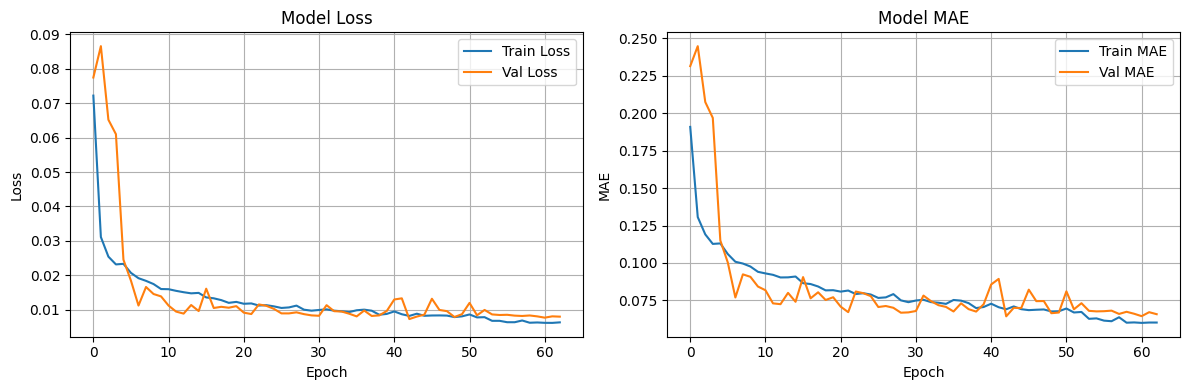

In [62]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Train
print("🚀 Training TCN model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training completed!")

# Vẽ loss curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [63]:
# Dự báo
print("📈 Making predictions...")
y_pred_scaled = model.predict(X_val)
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_val)

# Tách Revenue và COGS
pred_revenue = y_pred[:, 0]
pred_cogs = y_pred[:, 1]
true_revenue = y_true[:, 0]
true_cogs = y_true[:, 1]

# Đánh giá Revenue
print("\n" + "="*50)
print("REVENUE FORECAST RESULTS")
print("="*50)
rmse_rev = np.sqrt(mean_squared_error(true_revenue, pred_revenue))
mae_rev = mean_absolute_error(true_revenue, pred_revenue)
r2_rev = r2_score(true_revenue, pred_revenue)
print(f"RMSE: {rmse_rev:,.0f}")
print(f"MAE:  {mae_rev:,.0f}")
print(f"R²:   {r2_rev:.4f}")

# Đánh giá COGS
print("\n" + "="*50)
print("COGS FORECAST RESULTS")
print("="*50)
rmse_cogs = np.sqrt(mean_squared_error(true_cogs, pred_cogs))
mae_cogs = mean_absolute_error(true_cogs, pred_cogs)
r2_cogs = r2_score(true_cogs, pred_cogs)
print(f"RMSE: {rmse_cogs:,.0f}")
print(f"MAE:  {mae_cogs:,.0f}")
print(f"R²:   {r2_cogs:.4f}")

📈 Making predictions...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

REVENUE FORECAST RESULTS
RMSE: 772,284
MAE:  585,309
R²:   0.7891

COGS FORECAST RESULTS
RMSE: 716,116
MAE:  540,182
R²:   0.7537


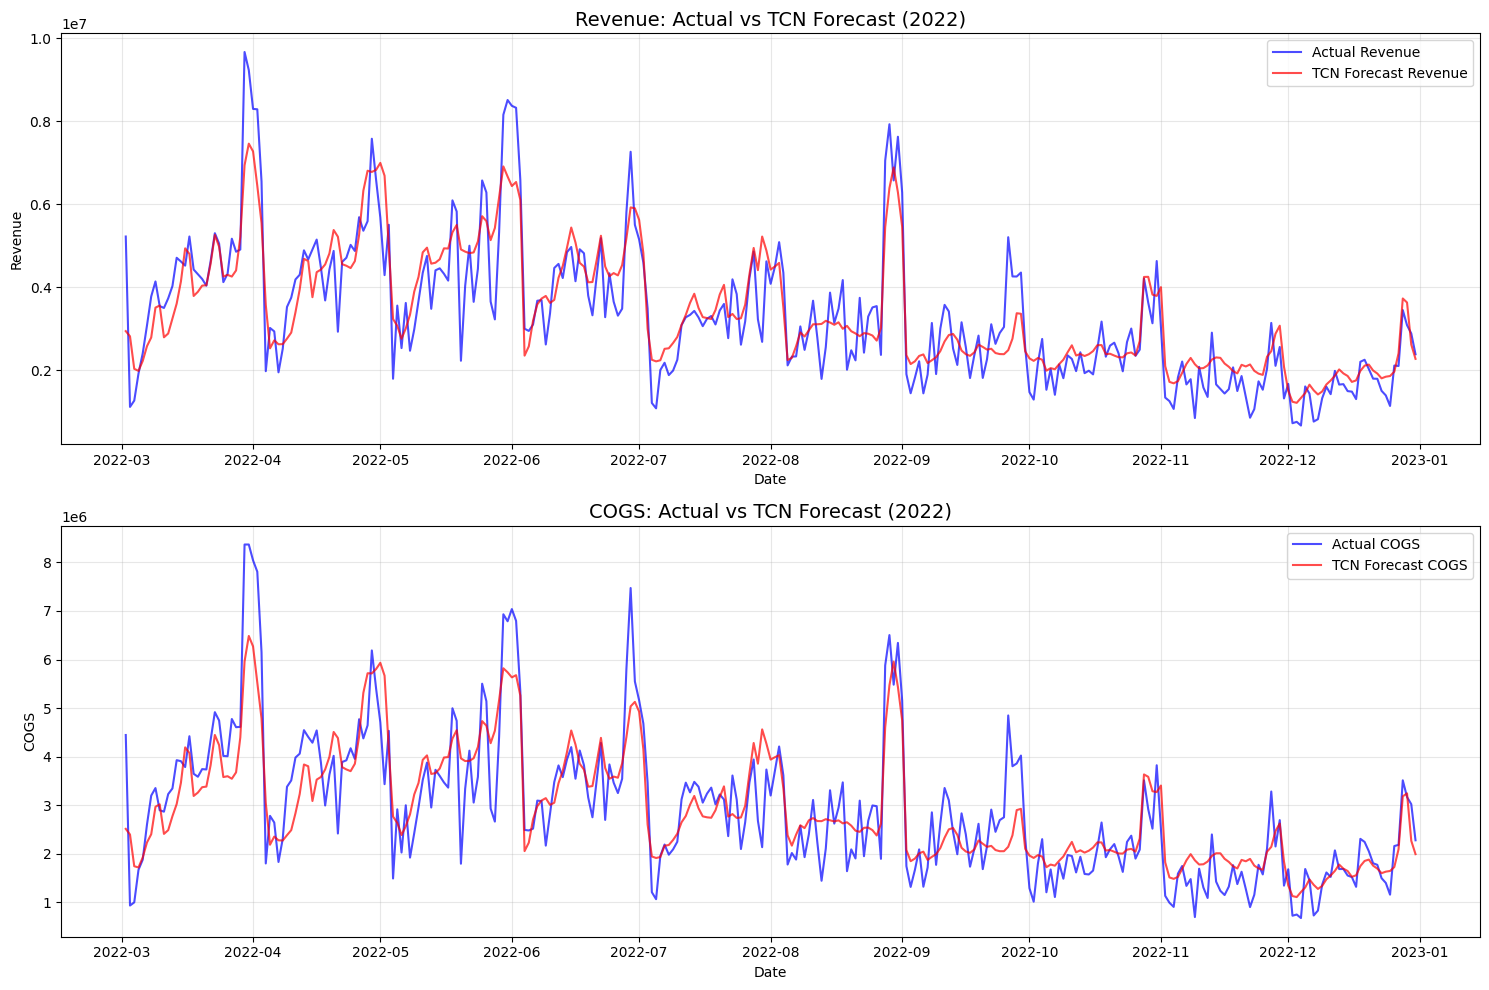

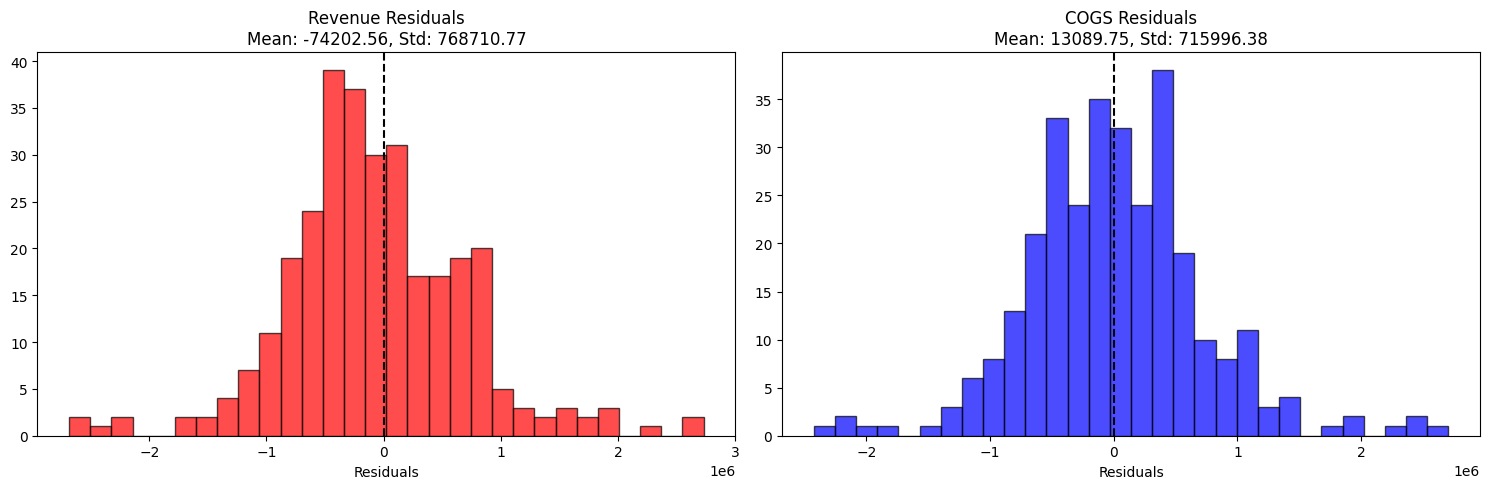

In [64]:
# Lấy dates cho validation (bỏ qua window_size ngày đầu)
val_dates = val_data['Date'].iloc[window_size:].reset_index(drop=True)

# Vẽ so sánh
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Revenue
axes[0].plot(val_dates, true_revenue, label='Actual Revenue', color='blue', alpha=0.7)
axes[0].plot(val_dates, pred_revenue, label='TCN Forecast Revenue', color='red', alpha=0.7)
axes[0].set_title('Revenue: Actual vs TCN Forecast (2022)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# COGS
axes[1].plot(val_dates, true_cogs, label='Actual COGS', color='blue', alpha=0.7)
axes[1].plot(val_dates, pred_cogs, label='TCN Forecast COGS', color='red', alpha=0.7)
axes[1].set_title('COGS: Actual vs TCN Forecast (2022)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('COGS')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residuals
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rev_residuals = true_revenue - pred_revenue
axes[0].hist(rev_residuals, bins=30, edgecolor='black', alpha=0.7, color='red')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title(f'Revenue Residuals\nMean: {rev_residuals.mean():.2f}, Std: {rev_residuals.std():.2f}')
axes[0].set_xlabel('Residuals')

cogs_residuals = true_cogs - pred_cogs
axes[1].hist(cogs_residuals, bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title(f'COGS Residuals\nMean: {cogs_residuals.mean():.2f}, Std: {cogs_residuals.std():.2f}')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

In [65]:
# Tạo future dates
future_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
print(f"Forecasting {len(future_dates)} days (2023-01-01 to 2024-07-01)")

# Tạo future features (dùng pattern từ quá khứ)
future_features = []

for future_date in future_dates:
    # Tìm ngày tương tự trong quá khứ (cùng month-day)
    mask = (data['Date'].dt.month == future_date.month) & (data['Date'].dt.day == future_date.day)
    similar_dates = data[mask]
    
    if len(similar_dates) > 0:
        similar_row = similar_dates.iloc[-1]
    else:
        similar_row = data.iloc[-1]
    
    row = {}
    for col in feature_columns:
        row[col] = similar_row[col]
    future_features.append(row)

future_df = pd.DataFrame(future_features)

# Scale
future_scaled = feature_scaler.transform(future_df)

# Dự báo (cần rolling prediction vì có lag features)
predictions = []
current_sequence = train_features_scaled[-window_size:].copy()

for i in range(len(future_dates)):
    # Dự báo 1 ngày
    X_pred = current_sequence[-window_size:].reshape(1, window_size, -1)
    y_pred_scaled = model.predict(X_pred, verbose=0)
    predictions.append(y_pred_scaled[0])
    
    # Cập nhật sequence cho ngày tiếp theo
    if i < len(future_dates) - 1:
        # Tạo feature vector cho ngày tiếp theo (cần cập nhật lags)
        next_features = future_scaled[i+1].copy()
        
        # Cập nhật lag features với giá trị vừa dự báo
        # (đơn giản hóa: dùng giá trị hiện tại cho lags)
        current_sequence = np.vstack([current_sequence, [future_scaled[i]]])
        current_sequence = current_sequence[-window_size:]

predictions = np.array(predictions)
predictions_unscaled = target_scaler.inverse_transform(predictions)

# Tạo submission
submission = pd.DataFrame({
    'Date': future_dates,
    'Revenue': predictions_unscaled[:, 0].clip(min=0),
    'COGS': predictions_unscaled[:, 1].clip(min=0)
})

print(f"\n✅ Submission shape: {submission.shape}")
print(submission.head(10))

# Lưu file
output_path = os.path.join(DATA_DIR, 'outputs', 'submission_tcn.csv')
submission.to_csv(output_path, index=False)
print(f"\n💾 Saved to: {output_path}")

Forecasting 548 days (2023-01-01 to 2024-07-01)

✅ Submission shape: (548, 3)
        Date      Revenue         COGS
0 2023-01-01  1981894.500  1738811.750
1 2023-01-02  1879509.750  1655500.750
2 2023-01-03  1494324.875  1328006.875
3 2023-01-04  1356389.750  1210667.875
4 2023-01-05  1308478.250  1175956.500
5 2023-01-06  1386766.125  1245075.000
6 2023-01-07  1261941.375  1134401.375
7 2023-01-08  1341955.875  1201463.875
8 2023-01-09  1702713.750  1504540.250
9 2023-01-10  1796098.375  1577793.500

💾 Saved to: ../data\outputs\submission_tcn.csv


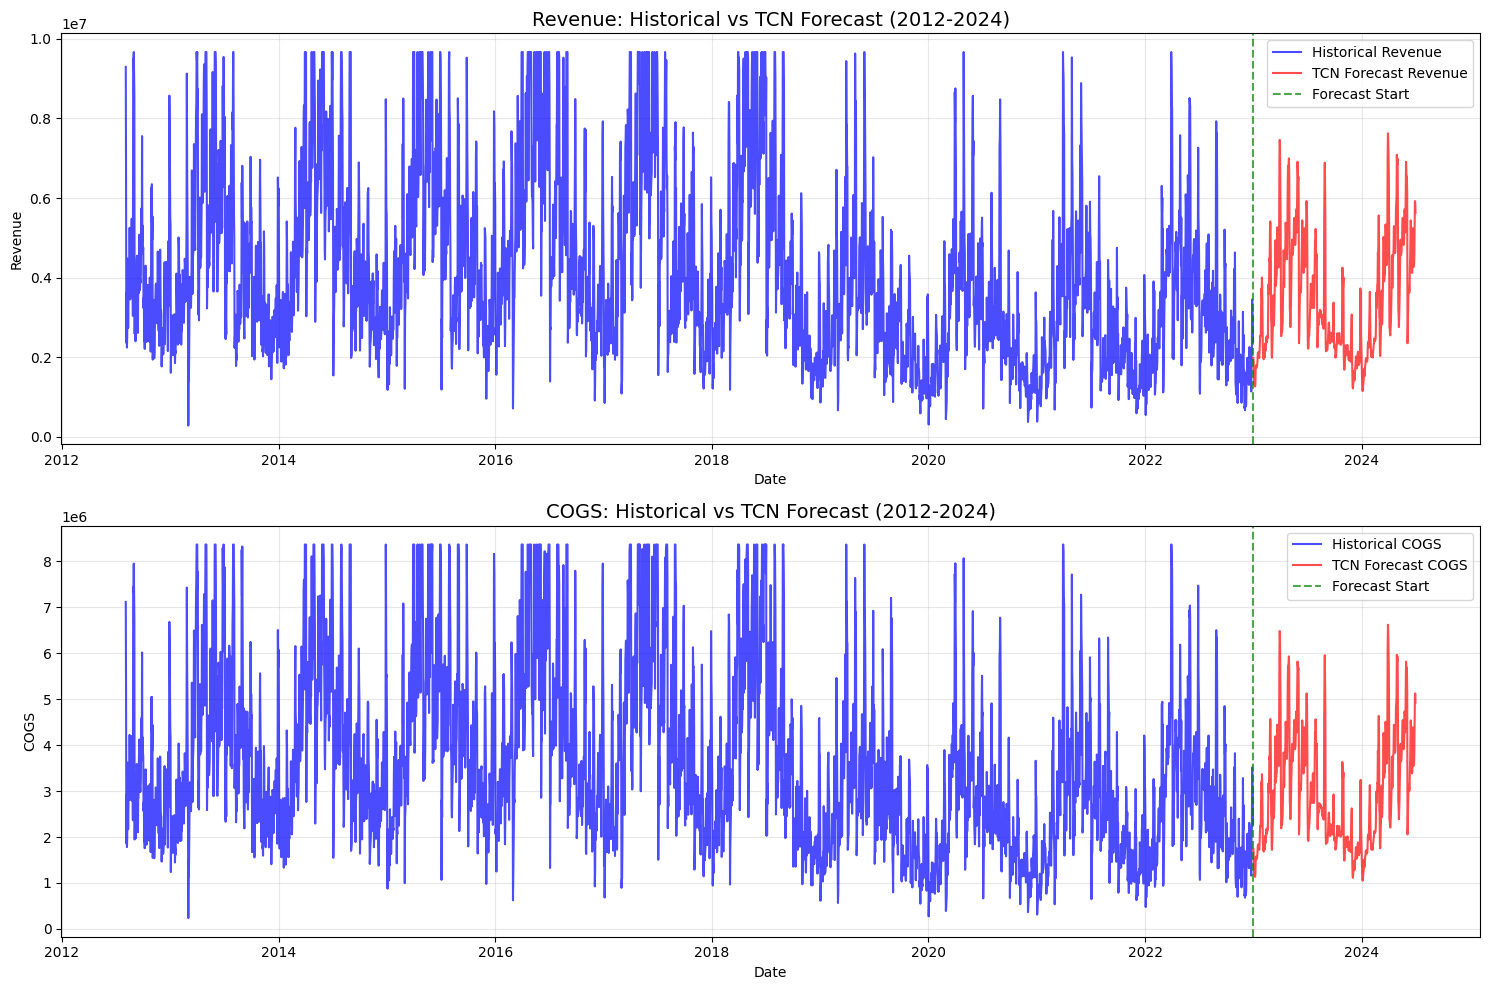


✅ TCN MODEL PIPELINE COMPLETED!


In [66]:
plt.figure(figsize=(15, 10))

# Revenue
plt.subplot(2, 1, 1)
plt.plot(data['Date'], data['Revenue'], label='Historical Revenue', color='blue', alpha=0.7)
plt.plot(future_dates, submission['Revenue'], label='TCN Forecast Revenue', color='red', alpha=0.7)
plt.axvline(x=pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.7, label='Forecast Start')
plt.title('Revenue: Historical vs TCN Forecast (2012-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)

# COGS
plt.subplot(2, 1, 2)
plt.plot(data['Date'], data['COGS'], label='Historical COGS', color='blue', alpha=0.7)
plt.plot(future_dates, submission['COGS'], label='TCN Forecast COGS', color='red', alpha=0.7)
plt.axvline(x=pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.7, label='Forecast Start')
plt.title('COGS: Historical vs TCN Forecast (2012-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("✅ TCN MODEL PIPELINE COMPLETED!")
print("="*50)